In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
import gradio as gr
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

2026-06-16 00:58:58.631658: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-16 00:59:01.023064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-16 00:59:01.841828: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-16 00:59:02.121310: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-16 00:59:03.805921: I tensorflow/core/platform/cpu_feature_guar

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-06-16 00:59:18.545445: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

[nltk_data] Downloading package punkt to /voc/work/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /voc/work/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /voc/work/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
df = pd.read_csv("amazon.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [4]:
df.shape

(1465, 16)

In [5]:
df.isna().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [6]:
# Remove rows where the rating_count value is missing
df = df.dropna(subset=['rating_count'])

In [7]:
df.shape

(1463, 16)

In [8]:
# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function to clean text
def clean_review(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()
        
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize words
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # Join cleaned tokens back into sentence
    return " ".join(cleaned_tokens)

In [9]:
# Apply cleaning function to review_content column
df['cleaned_review'] = df['review_content'].apply(clean_review)

# Display first 5 cleaned reviews
df[['review_content', 'cleaned_review']].head()

/usr/local/lib/python3.10/site-packages/bs4/__init__.py:435: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  warnings.warn(


,review_content,cleaned_review
0,Looks durable Charging is fine tooNo complains...,look durable charging fine toono complains cha...
1,I ordered this cable to connect my phone to An...,ordered cable connect phone android auto car c...
2,"Not quite durable and sturdy,https://m.media-a...",quite durable sturdy http medium amazon com im...
3,"Good product,long wire,Charges good,Nice,I bou...",good product long wire charge good nice bought...
4,"Bought this instead of original apple, does th...",bought instead original apple work r fast appl...


In [10]:
#pd.set_option('display.max_colwidth', None)

#df[['review_content', 'cleaned_review']].head()

In [11]:
# Remove unwanted symbols and convert columns to numeric values
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows where rating is missing
df = df.dropna(subset=['rating'])

df['discounted_price'] = (df['discounted_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False))
df['actual_price'] = (df['actual_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False))
df['discount_percentage'] = (df['discount_percentage'].str.replace('%', '', regex=False))

# Convert columns to numeric datatype
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')

In [12]:
summary_stats = df[['rating', 'discounted_price', 'actual_price', 'discount_percentage']].describe()
summary_stats

# The average product rating is approximately 4.10 out of 5, indicating generally positive customer feedback. Products receive an average discount of about 47.7%, suggesting that discounts are commonly used across the platform.
# The average discounted price is ₹3,125 compared to an average actual price of ₹5,445, showing that customers benefit from substantial price reductions. The large standard deviation in pricing indicates considerable variation in product prices across different categories.

,rating,discounted_price,actual_price,discount_percentage
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,4.096717,3129.981826,5453.087743,47.672367
std,0.289497,6950.548042,10884.467444,21.613905
min,2.000000,39.000000,39.000000,0.000000
25%,4.000000,325.000000,800.000000,32.000000
50%,4.100000,799.000000,1670.000000,50.000000
75%,4.300000,1999.000000,4321.250000,63.000000
max,5.000000,77990.000000,139900.000000,94.000000


In [13]:
# Count the number of reviews for each product
product_reviews = (df.groupby('product_name')['review_id'].count().reset_index(name='review_count'))

# Top 10 most reviewed products
most_reviewed = product_reviews.sort_values(by='review_count', ascending=False).head(10)

# Top 10 least reviewed products
least_reviewed = product_reviews.sort_values(by='review_count', ascending=True).head(10)

print("Most Reviewed Products")
display(most_reviewed)

print("\nLeast Reviewed Products")
display(least_reviewed)

## Group data by product name and count the number of reviews. Created a summary table containing review counts for each product. Sort products in descending order to identify the most reviewed products and the least reviewed products

Most Reviewed Products


,product_name,review_count
382,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",5
384,Fire-Boltt Phoenix Smart Watch with Bluetooth ...,4
972,"Samsung Galaxy M13 5G (Aqua Green, 6GB, 128GB ...",3
120,Ambrane 2 in 1 Type-C & Micro USB Cable with 6...,3
826,Portronics Konnect CL 20W POR-1067 Type-C to 8...,3
827,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,3
324,Duracell USB Lightning Apple Certified (Mfi) B...,3
117,Amazonbasics Nylon Braided Usb-C To Lightning ...,3
84,Amazon Basics USB Type-C to USB-A 2.0 Male Fas...,3
388,"Fire-Boltt Visionary 1.78"" AMOLED Bluetooth Ca...",3



Least Reviewed Products


,product_name,review_count
865,ProElite Faux Leather Smart Flip Case Cover fo...,1
875,ROYAL STEP Portable Electric USB Juice Maker J...,1
874,ROYAL STEP - AMAZON'S BRAND - Portable Electri...,1
873,RESONATE RouterUPS CRU12V2A | Zero Drop | UPS ...,1
872,"RC PRINT GI 790 Ink Refill for Canon G1000, G1...",1
871,"R B Nova Lint/Fabric Shaver for Cloths, Lint R...",1
870,Qubo Smart Cam 360 from Hero Group | Made in I...,1
869,Quantum RJ45 Ethernet Patch Cable/LAN Router C...,1
868,Quantum QHM-7406 Full-Sized Keyboard with (₹) ...,1
867,Proven® Copper + Mineral RO+UV+UF 10 to 12 Lit...,1


In [14]:
#Smartwatch products, particularly those from Fire-Boltt, generate the highest customer engagement based on review volume. High review counts often indicate strong market demand and increased customer interest.
# Products with very few reviews may suffer from limited visibility or lower sales performance.
# The business can leverage highly reviewed products in promotional campaigns while encouraging more customer feedback for under-reviewed products to improve trust and product visibility.

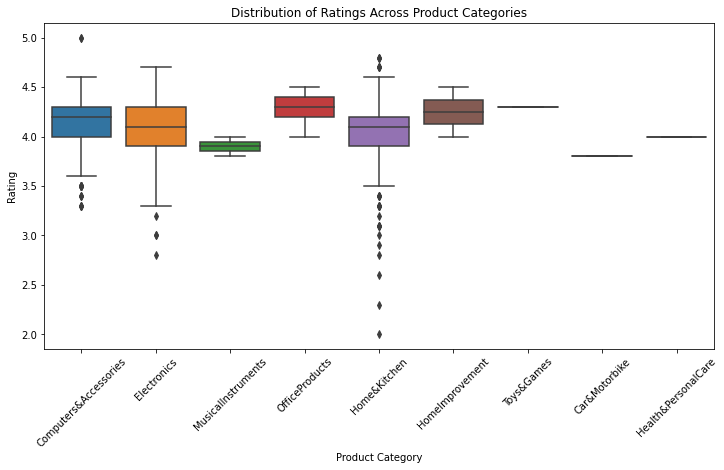

In [15]:
# Create a simplified category column. Extract the first main category from the hierarchical category field by splitting the text on "|" and selecting the first element.
df['main_category'] = df['category'].str.split('|').str[0]

# Plot rating distribution across categories
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x='main_category', y='rating')

plt.title('Distribution of Ratings Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.show()

# Most product categories have median ratings above 4.0, indicating generally positive customer satisfaction. Office Products and Home Improvement categories exhibit some of the highest median ratings, suggesting strong customer approval.
# Home & Kitchen products show the greatest variability in ratings and contain several low-rating outliers, indicating mixed customer experiences. Computers & Accessories and Electronics categories maintain relatively consistent ratings centered around 4.0 to 4.3.
# Toys & Games, Car & Motorbike, and Health & Personal Care appear to contain very few products in the dataset, which is why their distributions are represented by single lines rather than full boxplots.
# Overall, customer ratings are predominantly positive across categories, with most products receiving ratings above 4.0.

In [16]:
# Create review length feature (word count)
df['review_length'] = df['review_content'].apply(lambda x: len(str(x).split()))

# View sample results
df[['review_content', 'review_length']].head()

# Created a new feature representing the number of words in each customer review. Longer reviews may contain more detailed customer feedback and sentiment information

,review_content,review_length
0,Looks durable Charging is fine tooNo complains...,60
1,I ordered this cable to connect my phone to An...,201
2,"Not quite durable and sturdy,https://m.media-a...",13
3,"Good product,long wire,Charges good,Nice,I bou...",77
4,"Bought this instead of original apple, does th...",415


In [17]:
# Calculate sentiment polarity score using TextBlob
df['sentiment_polarity'] = df['review_content'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Display sample results
df[['review_content', 'sentiment_polarity']].head()

# Generated sentiment polarity scores from review text using TextBlob. Polarity values range from -1 (negative sentiment) to +1 (positive sentiment). 
#This feature captures customer sentiment directly from textual reviews

,review_content,sentiment_polarity
0,Looks durable Charging is fine tooNo complains...,0.481944
1,I ordered this cable to connect my phone to An...,0.274318
2,"Not quite durable and sturdy,https://m.media-a...",0.600000
3,"Good product,long wire,Charges good,Nice,I bou...",0.240370
4,"Bought this instead of original apple, does th...",0.262740


In [18]:
# Calculate price drop percentage from actual and discounted prices
df['price_drop_percentage'] = ((df['actual_price'] - df['discounted_price'])/ df['actual_price']) * 100

# Display sample results
df[['actual_price', 'discounted_price', 'price_drop_percentage']].head()

,actual_price,discounted_price,price_drop_percentage
0,1099.0,399.0,63.694268
1,349.0,199.0,42.979943
2,1899.0,199.0,89.520800
3,699.0,329.0,52.932761
4,399.0,154.0,61.403509


In [19]:
# Three new features were created to enrich the dataset:
# review_length captures the amount of customer feedback,
# sentiment_polarity measures review sentiment using NLP techniques,
# and price_drop_percentage quantifies product discount levels.
# These engineered features can improve predictive modeling performance by providing additional information beyond the original dataset attributes.

In [20]:
# Display the first 3 new features
df[['review_length', 'sentiment_polarity', 'price_drop_percentage']].head(3)

,review_length,sentiment_polarity,price_drop_percentage
0,60,0.481944,63.694268
1,201,0.274318,42.979943
2,13,0.600000,89.520800


In [21]:
# Generate descriptive statistics for the engineered features to understand their distribution and identify potential outliers.
df[['review_length', 'sentiment_polarity', 'price_drop_percentage']].describe()

,review_length,sentiment_polarity,price_drop_percentage
count,1462.000000,1462.000000,1462.000000
mean,240.920657,0.268318,47.665699
std,316.813372,0.138457,21.614122
min,13.000000,-0.600000,0.000000
25%,81.000000,0.177652,32.001280
50%,139.500000,0.253051,50.016672
75%,243.000000,0.350000,62.872861
max,2974.000000,1.000000,94.118824


In [22]:
# Feature Engineering Summary:
# The average review contains approximately 241 words, indicating that customers generally provide detailed feedback.
# Sentiment polarity scores have an average value of 0.27, suggesting that customer reviews are predominantly positive.
# Polarity scores range from -0.60 to 1.00, showing the presence of both negative and highly positive reviews.
# The average price drop percentage is approximately 47.68%, indicating that products are frequently sold at substantial discounts.
# Review length exhibits considerable variability, ranging from 11 to 2,974 words, suggesting significant differences in the level of detail provided by customers.
# The large spread in review length and discount percentages may introduce outliers that should be considered during predictive modeling.

In [23]:
# One-hot encode the main product category
category_encoded = pd.get_dummies(df['main_category'], prefix='category', drop_first=True)

# Merge encoded categories with the original dataset
df = pd.concat([df, category_encoded], axis=1)

# Display sample results
df.head()
# The main product category was transformed into numerical features using one-hot encoding. This enables machine learning models to utilize category information when making predictions.
# Product category may influence customer ratings and sentiment, making it a valuable predictor in the modeling process.

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,...,sentiment_polarity,price_drop_percentage,category_Computers&Accessories,category_Electronics,category_Health&PersonalCare,category_Home&Kitchen,category_HomeImprovement,category_MusicalInstruments,category_OfficeProducts,category_Toys&Games
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,0.481944,63.694268,1,0,0,0,0,0,0,0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",...,0.274318,42.979943,1,0,0,0,0,0,0,0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",...,0.600000,89.520800,1,0,0,0,0,0,0,0
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",...,0.240370,52.932761,1,0,0,0,0,0,0,0
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",...,0.262740,61.403509,1,0,0,0,0,0,0,0


In [24]:
# Convert cleaned review text into TF-IDF features
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df['cleaned_review'])
#check the actual vocabulary size
print(len(vectorizer.get_feature_names_out()))

vectorizer = TfidfVectorizer(max_features=5000) #keep vocabulary size to the first important 5000 unique features
X_tfidf = vectorizer.fit_transform(df['cleaned_review'])
# Display TF-IDF matrix shape
print(X_tfidf.shape)

# The full vocabulary contains 11,108 unique terms, which is relatively large compared to the dataset size. max_features=5000 is used to reduce dimensionality by keeping only the most informative terms.
# This helps improve model efficiency, reduce noise, and prevent overfitting.

11108
(1462, 5000)


In [25]:
# Create binary sentiment labels from ratings  [Target Variable]
df['sentiment'] = df['rating'].apply(lambda x: 'Positive' if x >= 3 else 'Negative')

# Check class distribution
df['sentiment'].value_counts()
# Ratings were transformed into binary sentiment labels for supervised classification. The dataset is highly imbalanced, with the majority of reviews classified as Positive.
# Class balancing techniques will be used to improve the model's ability to learn from the minority Negative class.

Positive    1456
Negative       6
Name: sentiment, dtype: int64

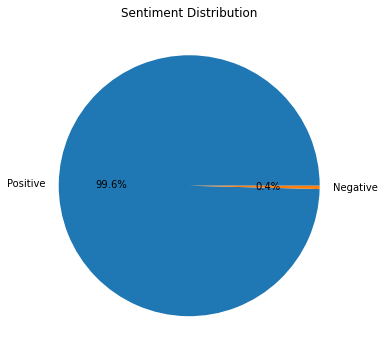

In [26]:
# Visualize the distribution of positive and negative customer reviews.
sentiment_counts = df['sentiment'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title('Sentiment Distribution')
plt.show()

# The dataset is highly imbalanced, with approximately 99.6% positive reviews and only 0.4% negative reviews. This indicates that customers generally have favorable opinions of the product.

In [27]:
X = X_tfidf
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Train traditional classification ML models
# Logistic Regression
lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
#Fit and Predict
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
#Fit and Predict
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
#Fit and Predict
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [28]:
#Models Evaluations
#Logistics Regression
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

#Decison Trees
print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

#Random Forest
print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

# Logistic Regression and Random Forest achieved the highest accuracy (99.66%), followed by Decision Tree (99.32%). Despite the high accuracy scores, all models failed to correctly classify the minority Negative class due to severe class imbalance in the dataset.

Logistic Regression
Accuracy: 0.9965870307167235
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       1.00      1.00      1.00       292

    accuracy                           1.00       293
   macro avg       0.50      0.50      0.50       293
weighted avg       0.99      1.00      0.99       293

[[  0   1]
 [  0 292]]

Decision Tree
Accuracy: 0.9931740614334471
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       1.00      1.00      1.00       292

    accuracy                           0.99       293
   macro avg       0.50      0.50      0.50       293
weighted avg       0.99      0.99      0.99       293

[[  0   1]
 [  1 291]]

Random Forest
Accuracy: 0.9965870307167235
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       1.00      1.00      1.00       292


/voc/work/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/voc/work/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/voc/work/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/voc/work/.local/li

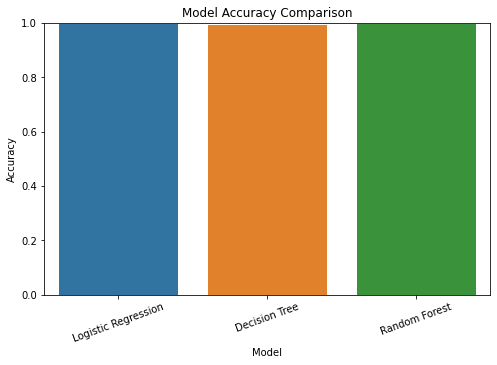

In [29]:

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

# Bar chart: model accuracy comparison
accuracy_scores = {}

for name, preds in models.items():
    accuracy_scores[name] = accuracy_score(y_test, preds)

plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

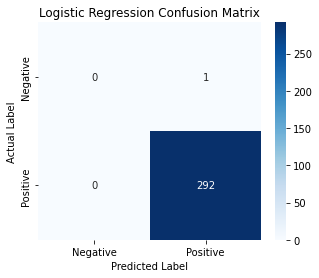

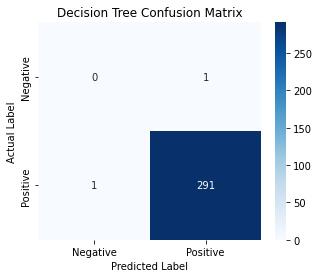

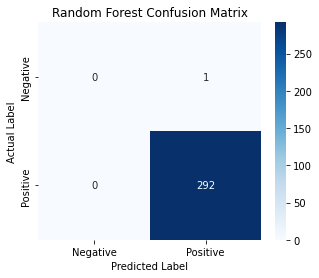

In [30]:
labels = ["Negative", "Positive"]

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels,
                yticklabels=labels)

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

In [31]:
#Train regression ML models to predict product ratings
X = X_tfidf
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train Linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

#Train Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

#Train Lasso Model
lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

In [32]:
#Evaluate models
#Linear Model
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.07965245366212088
RMSE: 0.2822276628222699
R2 Score: 0.026260805348606087


In [33]:
#ridge Model
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)
mae = mean_absolute_error(y_test, y_pred_ridge)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.05849349645309318
RMSE: 0.24185428764670097
R2 Score: 0.2849258558915493


In [34]:
#lasso Model
mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)
mae = mean_absolute_error(y_test, y_pred_lasso)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.07656997360093445
RMSE: 0.2767127998501957
R2 Score: 0.06394365771924249


In [35]:
# Ridge Regression achieved the best overall performance with the lowest MSE (0.0585), lowest RMSE (0.2419), and highest R² score (0.2849) among the three models.
# This indicates that Ridge Regression was most effective at predicting product ratings from TF-IDF review features.
# Customer review text contains useful information for predicting product ratings. However, the relatively low R² scores suggest that review text alone does not fully explain rating behavior.
# And Additional features could improve predictive performance.

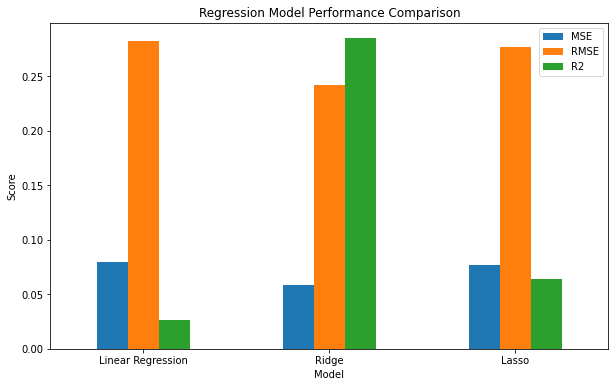

In [36]:
results = pd.DataFrame({
    'Model':['Linear Regression','Ridge','Lasso'],
    'MSE':[0.0797,0.0585,0.0766],
    'RMSE':[0.2822,0.2419,0.2767],
    'R2':[0.0263,0.2850,0.0639]
})

results.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Regression Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

In [37]:
# Define text feature and target variable
X_text = df['cleaned_review']
y = df['sentiment']

# Convert sentiment labels into numerical values
# Positive = 1, Negative = 0
y_encoded = y.map({'Positive': 1, 'Negative': 0})

# Split data into training and testing sets
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Tokenize review text and build a vocabulary from the training reviews.

# Text Preprocessing for Deep Learning:
# Customer reviews were transformed into numerical sequences using tokenization.
# Padding was applied to ensure a consistent sequence length across all reviews.
# The resulting padded sequences serve as input for LSTM and GRU deep learning models.
# This preprocessing enables the neural networks to learn patterns and relationships within customer review text.Only the 5,000 most frequent words are retained.
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

# Convert words into numerical sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences so all reviews have the same length
max_length = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Text Preprocessing for Deep Learning:
# Customer reviews were transformed into numerical sequences using tokenization. Padding was applied to ensure a consistent sequence length across all reviews. The resulting padded sequences serve as input for LSTM and GRU deep learning models.
# This preprocessing enables the neural networks to learn patterns and relationships within customer review text.

In [38]:
# Build LSTM model
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=5000, output_dim=64))
lstm_model.add(LSTM(64))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation='sigmoid'))

# Compile model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
lstm_history = lstm_model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)])

# Predict using LSTM model
y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int)

print("LSTM Model")
print("Accuracy:", accuracy_score(y_test, y_pred_lstm))
print(classification_report(y_test, y_pred_lstm, zero_division=0))
print(confusion_matrix(y_test, y_pred_lstm))

# The LSTM model achieved an accuracy of 99.66%. However, the model failed to correctly identify the only negative review in the test set, resulting in a precision, recall, and F1-score of 0.00 for the Negative class.
# The model successfully classified all positive reviews but demonstrated limited ability to learn the minority class due to the severe class imbalance.
# Consequently, the high accuracy should be interpreted with caution, as it is heavily influenced by the overwhelming number of positive reviews in the dataset.

Epoch 1/5


2026-06-16 00:59:50.125370: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9470 - loss: 0.4428 - val_accuracy: 0.9957 - val_loss: 0.0288
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9948 - loss: 0.0334 - val_accuracy: 0.9957 - val_loss: 0.0288
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9985 - loss: 0.0117 - val_accuracy: 0.9957 - val_loss: 0.0284
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9972 - loss: 0.0200 - val_accuracy: 0.9957 - val_loss: 0.0279
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9949 - loss: 0.0328 - val_accuracy: 0.9957 - val_loss: 0.0279
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
LSTM Model
Accuracy: 0.9965870307167235
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00       292

    accuracy                           1.00       293
   macro avg       0.50      0.50      0.50       293
weighted avg       0.99     

In [39]:
# Build GRU model
gru_model = Sequential()
gru_model.add(Embedding(input_dim=5000, output_dim=64))
gru_model.add(GRU(64))
gru_model.add(Dropout(0.3))
gru_model.add(Dense(1, activation='sigmoid'))

# Compile model
gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
gru_history = gru_model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)])

# Predict using GRU model
y_pred_gru_prob = gru_model.predict(X_test_pad)
y_pred_gru = (y_pred_gru_prob > 0.5).astype(int)

# Evaluate the GRU model
print("GRU Model")
print("Accuracy:", accuracy_score(y_test, y_pred_gru))
print(classification_report(y_test, y_pred_gru, zero_division=0))
print(confusion_matrix(y_test, y_pred_gru))

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9509 - loss: 0.4720 - val_accuracy: 0.9957 - val_loss: 0.0426
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9960 - loss: 0.0381 - val_accuracy: 0.9957 - val_loss: 0.0442
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9948 - loss: 0.0533 - val_accuracy: 0.9957 - val_loss: 0.0393
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9973 - loss: 0.0221 - val_accuracy: 0.9957 - val_loss: 0.0347
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9964 - loss: 0.0253 - val_accuracy: 0.9957 - val_loss: 0.0319
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
GRU Model
Accuracy: 0.9965870307167235
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00       292

    accuracy                           1.00       293
   macro avg       0.50      0.50      0.50       293
weighted avg       

In [40]:
# The dataset contains a severe class imbalance, with only 6 negative reviews out of 1,462 observations. As a result, the LSTM and GRU models were biased toward predicting the majority Positive class.

In [41]:
# Prepare review text for summarization
def prepare_for_summary(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Replace commas with periods to improve sentence separation
    text = text.replace(',', '. ')

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

df['summary_text'] = df['review_content'].apply(prepare_for_summary)

# This step prepares customer reviews for summarization by removing URLs, improving sentence separation, and eliminating unnecessary whitespace.
# The processed text is stored in a new column (summary_text) to preserve the original review_content) while creating cleaner input for the TextRank model.

In [42]:
# Define a TextRank-style extractive summarization function
def textrank_summary(text, top_n=2):
    
    # Convert text to string
    text = str(text)
    
    # Split review into sentences
    sentences = sent_tokenize(text)
    
    # Return original text if review is too short
    if len(sentences) <= top_n:
        return text
    
    # Convert sentences into TF-IDF vectors
    vectorizer = TfidfVectorizer(stop_words='english')
    sentence_vectors = vectorizer.fit_transform(sentences)
    
    # Calculate similarity between sentences
    similarity_matrix = cosine_similarity(sentence_vectors)
    
    # Score each sentence by summing its similarity with other sentences
    sentence_scores = similarity_matrix.sum(axis=1)
    
    # Select top-ranked sentence indexes
    ranked_sentence_indexes = sentence_scores.argsort()[-top_n:]
    
    # Sort selected sentences back into original order
    ranked_sentence_indexes = sorted(ranked_sentence_indexes)
    
    # Join selected sentences into summary
    summary = " ".join([sentences[i] for i in ranked_sentence_indexes])
    
    return summary

# This function implements a TextRank-style extractive summarization approach. Reviews are split into sentences, converted into TF-IDF vectors, and compared
# using cosine similarity. Sentences with the highest importance scores are selected and combined to generate a concise summary while retaining key information.

In [43]:
# Apply TextRank-style summarization to the first 10 reviews
df_sample = df.head(8).copy()

df_sample['review_summary'] = df_sample['summary_text'].apply(lambda x: textrank_summary(x, top_n=2))

pd.set_option('display.max_colwidth', 300)
# Display original review and generated summary
df_sample[['review_content', 'review_summary']]

# Applied the TextRank summarization model to a sample of customer reviews. The top two most important sentences are selected from each review and
# stored as review summaries. The original reviews and generated summaries are displayed side-by-side for comparison and evaluation.

,review_content,review_summary
0,"Looks durable Charging is fine tooNo complains,Charging is really fast, good product.,Till now satisfied with the quality.,This is a good product . The charging speed is slower than the original iPhone cable,Good quality, would recommend,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/...",good product.. Till now satisfied with the quality.. Good quality.
1,I ordered this cable to connect my phone to Android Auto of car. The cable is really strong and the connection ports are really well made. I already has a Micro USB cable from Ambrane and it's still in good shape. I connected my phone to the car using the cable and it got connected well and no i...,Good. Good.
2,"Not quite durable and sturdy,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/71rIggrbUCL._SY88.jpg,Working good,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/61bKp9YO6wL._SY88.jpg,Product,Very nice product,Working well,It's a really nice product",nice product. It's a really nice product
3,"Good product,long wire,Charges good,Nice,I bought this cable for Rs.339 worthy product for this price, i tested it in various charger adapters 33w and 18w it supports fast charging as well.,Good,Ok,I had got this at good price on sale on Amazon and product is useful with warranty but for warrant...",Good product. I like this product
4,"Bought this instead of original apple, does the work for 150rs, not as fast as apple charger but its a good option if you want cheap and good product, bought it for iPad pro 10.5 and it's working flawlessly, build quality is ok, its not like i am gonna hang my clothes on it and i want a very str...",i have used both Anker and Apple store strong braided cable they all stop working after a year so please don't buy high end cables just for that instead choose a this one and even if it's stops working withing a year you only loose 150rs compares to 2000rs.UPDATE---------------------------------...
5,"It's a good product.,Like,Very good item strong and useful USB cableValue for moneyThanks to amazon and producer,https://m.media-amazon.com/images/I/51112ZRE-1L._SY88.jpg,Good,Nice product and useful product,-,Sturdy but does not support 33w charging",It's a good product.. Like. product and useful product.
6,"Build quality is good and it is comes with 2 year warranty.,Good Product,Bought it for charging my mobile & tab but it doesn't work for Lenovo m8 tab,Guys this cable is is best compare of everyone over heat protection, quickly charging, but chance to shock circuit,good,Nice,Good quality,1.5एम का...",good. Good quality.
7,"Worth for money - suitable for Android auto... my purpose served in car....got it for Rs.150,Everything is Okay. But packaging is not good feeling like seller gave is used cable.,Good product,Good product but cost is more.,Original cable,I bought this cable at 129. Using this cable for Android a...",Original cable. The charging speed is exactly half of my 67 watt original cable.


In [44]:
# Function for Gradio app

def summarize_reviews(user_input):

    reviews = user_input.split('|')
    cleaned_reviews = [
        prepare_for_summary(review)
        for review in reviews
        if review.strip() != ""
    ]

    combined_reviews = " ".join(cleaned_reviews)
    summary = textrank_summary(combined_reviews, top_n=2)

    return summary

# This function processes user-entered customer reviews from the Gradio interface. Reviews are separated using the pipe symbol, cleaned using the preprocessing function, combined into a single document, and passed to the TextRank summarization model.
# The generated summary is returned and displayed to the user through the web app.

In [45]:
# Build Gradio interface

app = gr.Interface(
    fn=summarize_reviews,
    inputs=gr.Textbox(lines=8, placeholder="Enter multiple reviews separated by |", label="Customer Reviews"),
    outputs=gr.Textbox(lines=5, label="Generated Review Summary"),
    title="Customer Review Summarization App",
    description="Enter multiple customer reviews separated by a pipe symbol (|). The app generates a concise summary using a TextRank-style NLP model."
)
#app.launch(share=True)


# Test the summarization function directly without launching Gradio
sample_input = """
This product is very good and charges fast. | I like the quality. |
The cable is durable and works well with my phone. |
Good value for money and I would recommend it. | Delivery was superb. |
"""

summary = summarize_reviews(sample_input)
print(summary)
#app.launch(share=True)


IMPORTANT: You are using gradio version 3.45.2, however version 4.44.1 is available, please upgrade.
--------
This product is very good and charges fast. Good value for money and I would recommend it.


In [46]:
# A Gradio-based review summarization application was developed and connected to a TextRank-style extractive summarization model. 
# The application accepts multiple customer reviews as input and automatically generates a concise summary of customer feedback.
# Due to environment restrictions preventing localhost deployment, the summarization function was validated using sample user input to demonstrate the application's functionality.

In [ ]:
#Conclusion:
# Built a full NLP pipeline 
# Classified sentiment 
# Predicted product ratings 
# Summarized reviews 
# Created app logic for interactive use

#Future improvements:
# Collect more balanced negative review data 
# Implement a more effective class imbalance handling technique, [SMOTE] to generate synthetic data for the minority class to enhance a balanced dataset.